## Importação do arquivo direto do Kaggle

In [64]:
import kagglehub
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = kagglehub.dataset_download("namespaiva/base-varejo")

df = pd.read_csv(os.path.join(path, "Base Varejo.csv"), sep=";")



Using Colab cache for faster access to the 'base-varejo' dataset.


## Leitura rápida do arquivo
Para conhecer o conteúdo do arquivo foi usado .info(), para ver o número total de registros e colunas e se há nulos. E por meio do .head() foi possível conhecer os dados informados ou não nos registros.

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  object 
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  object 
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  object 
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  object 
 9   PR_NOME      830000 non-null  object 
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), object(5)
memory usage: 88.7+ MB


In [66]:

df.head()

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN


## Identificando nulos e fazendo a limpeza.
Foi usado .isnull() e .sum() para identificar e somar os nulos de cada coluna

Foi identificado que apenas as 4 últimas colunas (Unnamed: 10, Unnamed: 11, Unnamed: 12 e Unnamed: 13) possuem valores nulos e em todos os registros. Por esse motivo, essas colunas foram excluídas. E para tanto foi usado drop() e o parâmetro columns para especificar as colunas para a exclusão.

In [67]:
df.isnull().sum()

,0
DATA,0
CO_ID,0
CL_ID,0
CL_GENERO,0
CL_EC,0
CL_FHL,0
CL_SEG,0
PR_ID,0
PR_CAT,0
PR_NOME,0


In [68]:
df = df.drop(columns=['Unnamed: 10','Unnamed: 11','Unnamed: 12','Unnamed: 13'])

## Conhecendo os tipos de dados em cada coluna e convertendo quando necessário
Foi constatado que apenas a data da compra está com o tipo de dados incompatível, que no caso é object. E também estava no formato padrão brasileiro ('%d/%m/%Y') Portanto foi convertido para datetime.

Para tanto foi usado o pd.to_datetime e o parâmetro format='%d/%m/%Y' por conta do formato brasileiro de data.

Os tipo de dados dos IDs e de CL_EC (Estado civil)  são int e não precisam ser alterados, devido os dados serem apenas números inteiros.

CL_EC não possui outra coluna que seja referência para a identificação de nomenclaturas correspondentes aos códigos numéricos contidos em CL_EC. Por essa razão, não apresenta dados relevantes para análises e, portanto, não será feito ateração.

In [69]:
df.dtypes

,0
DATA,object
CO_ID,int64
CL_ID,int64
CL_GENERO,object
CL_EC,int64
CL_FHL,int64
CL_SEG,object
PR_ID,int64
PR_CAT,object
PR_NOME,object


In [70]:
df["DATA"] = pd.to_datetime(df["DATA"], format='%d/%m/%Y')
df.dtypes

,0
DATA,datetime64[ns]
CO_ID,int64
CL_ID,int64
CL_GENERO,object
CL_EC,int64
CL_FHL,int64
CL_SEG,object
PR_ID,int64
PR_CAT,object
PR_NOME,object


## Vendo se tem registros duplicados
No total foram encontrados 96.553 registro duplicados. Porém como se trata de compras de produtos, entende-se e é comum, que tais produtos podem ter sido comprados mais de uma unidade na mesma compra. Por essa razão, esses registros duplicados não foram excluídos. De outra forma, a exclusão indiscriminada poderia remover registros válidos, já que não foi possível identificar duplicatas que fossem comprovadamente inconsistentes.

Para tanto foram usadas as funçoes duplicated e sum


In [71]:
df.duplicated().sum()

np.int64(96553)

## Vendo se os dados que são string estão padronizados e se tem algum erro.

Os dados das colunas `PR_CAT` e `PR_NOME` estão padronizados e não há duplicata parcial com valores com difereças sutis.

Foi identificado que nas colunas `PR_CAT` e `PR_NOME` há linhas com valores desconhecidos ("#N/D") associado ao `PR_ID` de nº 107 e foram contados 3650 registros tanto para esse ID produto, quanto para essas colunas com valores desconhecidos. Ou seja, como é conhecido que esse produto é o único que tem valores desconhecidos e não há nenhuma linha com esse ID que pudesse identificar esses valores para esse mesmo produto, todos esses registros foram excluídos.

Para tanto, foi usado a função **unique** para indicar elementos únicos e foi usado **condição** para checar valor desconhecido. Foi usado também **replace("#N/D", np.nan)** para transformar valor desconhecido em nulo e depois usado **dropna** para exlcuir os valores nulos.

E foi criado uma nova base com o nome (**df_limpo**), a fim de ser usada quando a análise é afetada pela ausência desses valores.

Porém, não podemos negar que o produto existe, que tem o seu `PR_ID` de nº. 107 e apenas o nome e a categoria não são fornecidos. Portanto, para as análises que não são afetadas por esses valores ausentes, esses registros podem ser mantidos na base (**df**).

Por fim, foram consideradas apenas as colunas que serão úteis para as análises.


In [72]:
df['PR_CAT'].unique()

array(['BEBIDAS', 'HIGIENE', 'ALIMENTOS', 'LIMPEZA', 'ACESSORIOS', 'PET',
       '#N/D'], dtype=object)

In [73]:
df['PR_NOME'].unique()

array(['REFRIGERANTE GUARANA', 'REFRIGERANTE OUTROS', 'LENCO UMEDECIDO',
       'ABACAXI', 'LIMPADOR MULTIUSO', 'HASTES FLEXIVEIS', 'MORTADELA',
       'AZEITE', 'AMACIANTE', 'ENERGETICO', 'LATA DE ERVILHA',
       'PRESERVATIVO', 'BANANA', 'DETERGENTE', 'BIFE DE COXAO MOLE',
       'PAPEL HIGIENICO', 'UVA', 'LIMPA VIDROS', 'RICOTA', 'REMOVEDOR',
       'REFRIGERANTE LIMaO', 'QUEIJO MUSSARELA', 'SARDINHA', 'FRALDA',
       'GRANOLA', 'RODO', 'ARROZ INTEGRAL', 'COGUMELOS', 'PATE',
       'PALMITO', 'ATUM', 'TIRA MANCHA', 'CORACAO DE FRANGO', 'ALMONDEGA',
       'SABONETE', 'COPA SUINA', 'KETCHUP', 'REFRIGERANTE COLA',
       'REFRIGERANTE LARANJA', 'REPELENTE', 'LEITE CONDENSADO', 'ALCOOL',
       'MORDEDOR', 'ESCOVA DE DENTE', 'RACAO UMIDA PARA GATOS', 'OVOS',
       'MAMAO PAPAYA', 'SABAO', 'CAFE', 'LUSTRA MOVEIS', 'CONDICIONADOR',
       'SALGADINHOS DE MILHO', 'LEITE', 'DESINFETANTE', 'CHUPETA',
       'FIXADOR', 'ALHO', 'TINTURAS', 'PASTA DE DENTE',
       'RACAO SECA PARA CAES', '

In [74]:
df_check = df[(df[['PR_CAT', 'PR_NOME']] == '#N/D').any(axis=1)]
display(df_check.head(20))

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
82,2019-02-01,1078,290,F,1,0,B,107,#N/D,#N/D
223,2019-02-01,1103,957,M,2,3,B,107,#N/D,#N/D
640,2019-02-01,1482,453,F,1,0,B,107,#N/D,#N/D
857,2019-02-01,1683,438,F,1,0,B,107,#N/D,#N/D
917,2019-02-01,1793,608,F,3,0,C,107,#N/D,#N/D
1185,2019-02-01,2151,493,M,2,4,B,107,#N/D,#N/D
1273,2019-02-01,2224,497,M,3,0,B,107,#N/D,#N/D
1303,2019-02-01,2311,164,M,2,3,A,107,#N/D,#N/D
1325,2019-02-01,2311,164,M,2,3,A,107,#N/D,#N/D
1385,2019-02-01,2327,689,M,2,0,C,107,#N/D,#N/D


In [75]:
df_nd = df.loc[df['PR_ID'] == 107]
display(df_nd['PR_ID'].count())

np.int64(3650)

In [76]:
df_nd = df.loc[df['PR_CAT'] == "#N/D"]
display(df_nd["PR_CAT"].count())

np.int64(3650)

In [77]:
df_nd = df.loc[df['PR_NOME'] == "#N/D"]
display(df_nd["PR_NOME"].count())

np.int64(3650)

#### Considerando apenas as colunas úteis para as análises

In [78]:
mantendo_apenas_colunas_uteis = ['DATA', 'CL_ID', 'CL_GENERO', 'CL_FHL', 'PR_CAT']
df = df[mantendo_apenas_colunas_uteis]

#### Transformando os valores desconhecidos em nulo;
#### E criando uma nova base, limpando as linhas com nulo.

In [79]:
df = df.replace("#N/D", np.nan)

# Criando uma base sem os valores nulos
df_limpo = df.dropna()

# Verificando o novo formato
print(f"Shape do df com valores nulos: {df.shape}")
print(f"Shape do df_limpo sem os valores nulos: {df_limpo.shape}")

Shape do df com valores nulos: (830000, 5)
Shape do df_limpo sem os valores nulos: (826350, 5)


## Estatísticas de Filhos dos Clientes (CL_FHL)

Com base na análise da coluna `CL_FHL`, obtivemos os seguintes indicadores para os 830.000 registros:

*   **Média:** 1,15 filhos por cliente.
*   **Mediana:** 0 (indicando que pelo menos 50% da base não possui filhos registrados).
*   **Moda:** 0 (o valor mais frequente).
*   **Desvio Padrão:** 1,42.
*   **Máximo:** 4 filhos.
*   **Mínimo:** 0 filhos.
*   **Contagem de Registros:** 830.000.
*   **Qtd. total:** 1136 filhos no total

Para tanto, foi usado o método **.agg** para aplicar várias funções de agregação ou resumo para a coluna `CL_FHL`. A obtenção do valor de moda e quantidade total de filhos foram obtidos a parte por não serem compativeis com o método. Já na obtenção da quantidade total de filhos foram usadas combinações de agrupamentos: **groupby** para agrupar por cliente, **first** para considerar o valor do primeiro resgistro de `CL_FHL`, para não repetir valores e, por fim, **sum** para fazer a soma da quantidade.

Observou-se que a quantidade de filhos por cliente não ultrapassa 4, um valor condizente com o esperado para a base de dados.

A mediana e a moda iguais a 0 indicam que o valor mais frequente é a ausência de filhos registrados e que pelo menos metade dos registros possui até 0 filhos. A quantidade registrada varia de 0 a 4 filhos.

A Qtd. total de filhos é baseada apenas nos clientes que tem o resgistro de mais de 1 filho.


In [80]:
estatisticas_fhl = df['CL_FHL'].agg(['mean', 'median', 'std', 'max', 'min', 'count'])

# Obtenção da moda e Qtd em separado
estatisticas_fhl['mode'] = df['CL_FHL'].mode()[0]
estatisticas_fhl['Qtd'] = df.groupby('CL_ID')['CL_FHL'].first().sum()

print(estatisticas_fhl)


mean           1.14654
median         0.00000
std            1.41696
max            4.00000
min            0.00000
count     830000.00000
mode           0.00000
Qtd         1136.00000
Name: CL_FHL, dtype: float64


## Qual sexo faz mais compras?
Total de compras:

* **Feminino**	432576
* **Masculino**	397424

O gráfico mostra a contagem total de compras para cada gênero (`F` para feminino e `M` para masculino). Não há uma diferença significativa, mas foi como esperado.

Foram usadas as bibliotecas **matplotlib** e **seaborn** para construir o gráfico. E foi usado **groupby** para agrupar os sexos e fazer a contagem de compras usando **.size**, como regra de negócio, tendo em vista que cada registro foi uma compra de cada produto.

In [81]:
# Quantidade de compras por gênero
df.groupby('CL_GENERO').size()

,0
CL_GENERO,
F,432576
M,397424


/tmp/ipykernel_684/2527295209.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Genero', y='Quantidade', data=compras_genero, palette='viridis')


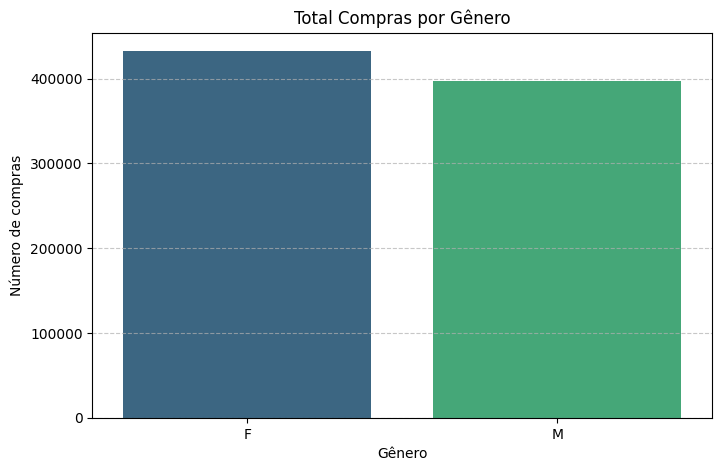

In [82]:
# Criando um gráfico de barras.

compras_genero = df.groupby('CL_GENERO').size().reset_index(name='Quantidade')
compras_genero.columns = ['Genero', 'Quantidade']

fig = plt.figure(figsize=(8, 5))
sns.barplot(x='Genero', y='Quantidade', data=compras_genero, palette='viridis')
plt.title('Total Compras por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Número de compras')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Variações de vendas ao longo do tempo
Aqui também foi utilizado **groupby()** e o método **.size** sobre a coluna Periodo (mês e ano), para observar como a quantidade de registros de compras varia ao longo do tempo por Mes/Ano.

Permite identificar períodos com maior ou menor movimentação de vendas.

#### Preparando os dados
Primeiro foi necessário criar a coluna na base **df** com o formato de data mês e ano usando **dt.to_period('M')** para poder ser agrupado depois em outra variável usando o **groupby**, o **size** para obeter a quantidade de repetições dentro do grupo e o **reset_index** para criar uma coluna para esse dado usando o parâmetro **name** para nomea-la. Também foi usado o método **columns** na variável para nomear e definir as colunas. Antes de formatar a data `Periodo` usando **pd.strftime** (str) para o formato desejado, foi usado a **sort_values** para ordenar cronologicamente.

In [83]:
# Criando a coluna Período na base df e variável Recebendo Periodo da base df
df['Periodo'] = df['DATA'].dt.to_period('M')
compras_periodo = df["Periodo"]

# Agrupando períodos e criando a coluna Quantidade com o tamanho de cada agrupamento
compras_periodo = df.groupby('Periodo').size().reset_index(name='Quantidade')
compras_periodo.columns = ['Periodo', 'Quantidade']

# colocando em órdem cronológica
compras_periodo = compras_periodo.sort_values('Periodo')

# Mudando o formato da data na coluna Periodo
compras_periodo['Periodo'] = compras_periodo['Periodo'].dt.strftime('%m/%Y')

In [84]:
compras_periodo.head(48)

,Periodo,Quantidade
0,01/2019,7368
1,02/2019,18336
2,03/2019,11051
3,04/2019,18337
4,05/2019,31811
5,06/2019,22084
6,07/2019,12184
7,08/2019,17900
8,09/2019,19122
9,10/2019,10245


#### Criando o gráfico de 2019 a 2020

Para filtrar os anos e como os períodos estão no formato object, foi usado o método **str** para sinalizar os índices as serem percorridos na filtragem. Foi colocado como parâmetro -4 para correr do fim para o início, a fim de ser considerado apenas o ano em questão. Para a filtragem do ano foi usado o **isin**

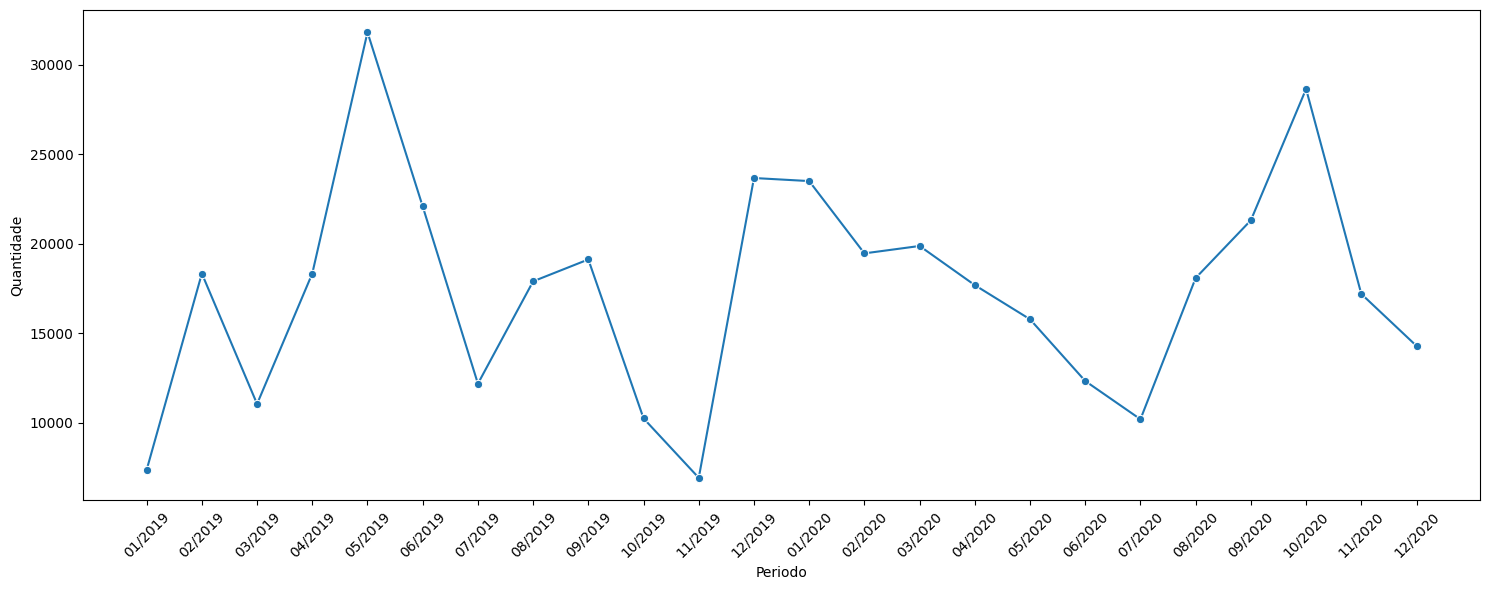

In [85]:
# Filtrando o período
compras_2019_2020 = compras_periodo[compras_periodo['Periodo'].str[-4:].isin(['2019', '2020'])]

# Criando o gráfico
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=compras_2019_2020,
    x='Periodo',
    y='Quantidade',
    marker='o'
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


#### Criando o gráfico de 2021 a 2022
Foi usado o mesmo método anterior para a filtragem

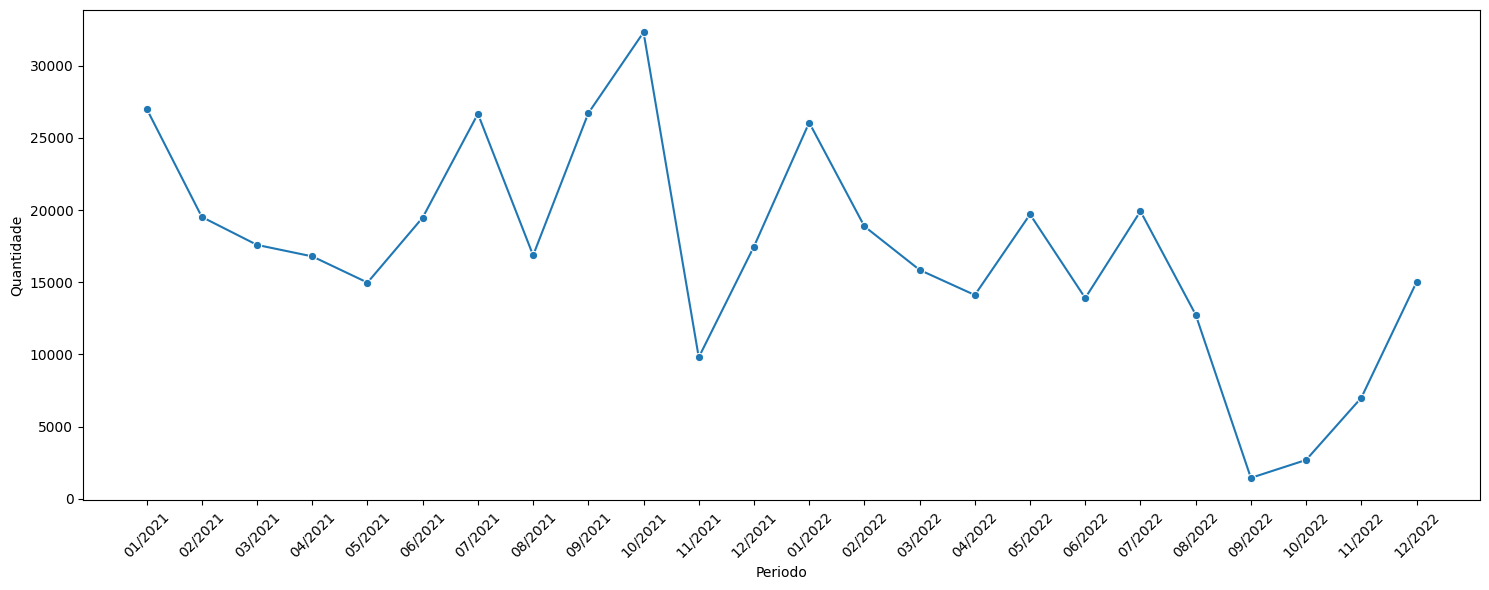

In [86]:
# Filtrando o período
compras_2021_2022 = compras_periodo[compras_periodo['Periodo'].str[-4:].isin(['2021', '2022'])]

# Criando o gráfico
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=compras_2021_2022,
    x='Periodo',
    y='Quantidade',
    marker='o'
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Quais categorias vendem mais?

* 1º	**ALIMENTOS**	434767
* 2º	**HIGIENE**	155574
* 3º	**LIMPEZA**	145754
* 4º	**BEBIDAS**	43299
* 5º	**PET**	32399
* 6º	**ACESSORIOS**	14557

Aqui foi usada a base df_limpo onde foi eliminada a categoria com valor desconhecido.
Também foi usado **groupby()** para fazer o agrupamento por categoria e então poder fazer a contagem de registros por categoria.

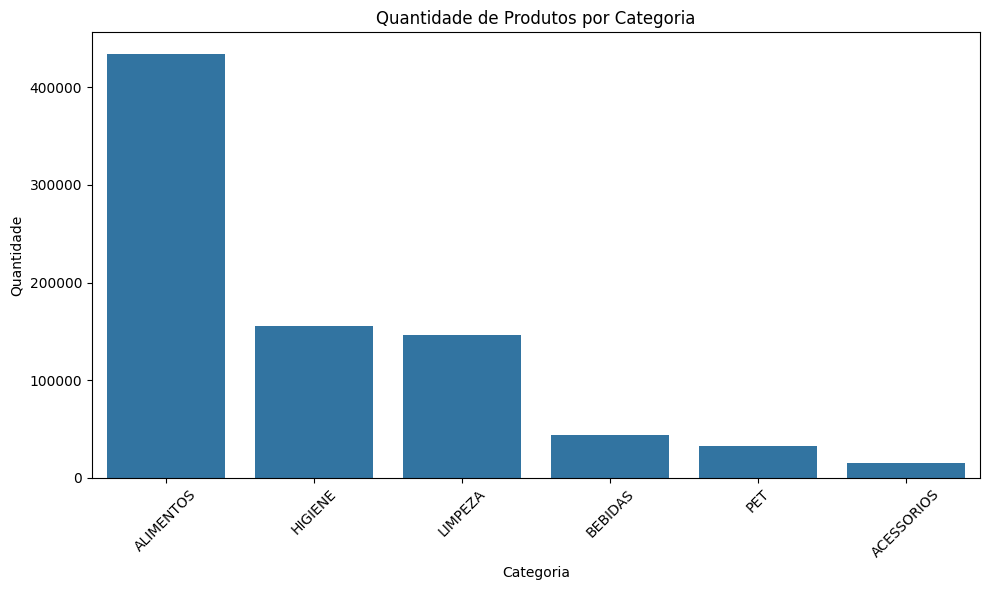

,Categoria,Quantidade
0,ALIMENTOS,434767
1,HIGIENE,155574
2,LIMPEZA,145754
3,BEBIDAS,43299
4,PET,32399
5,ACESSORIOS,14557


In [87]:
categoria_mais_vendida = df_limpo.groupby('PR_CAT').size().sort_values(ascending=False)
categoria_mais_vendida = categoria_mais_vendida.reset_index(name='Quantidade')
categoria_mais_vendida.columns = ['Categoria', 'Quantidade']

plt.figure(figsize=(10, 6))
sns.barplot(x='Categoria', y='Quantidade', data=categoria_mais_vendida)
plt.xticks(rotation=45)
plt.title('Quantidade de Produtos por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Quantidade')

plt.tight_layout()
plt.show()

categoria_mais_vendida.head(6)

## Conclusões

* A base possui **830.000 registros inicialmente**, distribuídos em 14 colunas. Após a exclusão das quatro colunas totalmente nulas, a análise passou a utilizar 10 colunas relevantes.
* Foram identificados **3.650 registros associados ao `PR_ID` 107**, nos quais as informações de categoria e nome do produto estão como `#N/D`. Esses registros foram tratados como valores ausentes e uma base `df_limpo`, com **826.350 registros**, foi criada para análises que dependem dessas informações limpas.
* A quantidade de filhos (`CL_FHL`) apresenta **média de aproximadamente 1,15**, enquanto a mediana e a moda são 0. Isso indica uma concentração relevante de registros de clientes sem filhos informados, com valores variando de 0 a 4.
* Na análise por gênero, foram registrados **432.576 registros para o gênero feminino e 397.424 para o masculino**, indicando maior quantidade de registros associados ao gênero feminino, embora a diferença não seja muito grande.
* Analisando as vendas nos períodos de 2019–2020, identificaram-se os menores volumes de vendas nos meses de janeiro/2019 (7.368 unidades), novembro/2019 (6.927 unidades) e julho/2020 (10.197 unidades), representando os pontos de menor retração da receita na amostragem. Já nos períodos de 2021–2022 após a redução sazonal prevista para agosto/2022, observou-se uma retração atípica em setembro/2022, atingindo o menor patamar registrado no período (1.442 unidades). O indicador iniciou uma recuperação gradual no mês subsequente, alcançando a estabilização das operações apenas em dezembro/2022. A categoria de Alimentos lidera amplamente as vendas com 434.767 unidades, enquanto a de Acessórios registra o menor volume, com apenas 14.557 unidades.
* Como ponto de atenção remanescente, a base ainda possui **96.553 registros duplicados**. Eles foram mantidos por não ser possível determinar, apenas com as colunas disponíveis, quais duplicidades representam erros e quais podem corresponder a registros legítimos de produtos repetidos.
